# Within-dataset benchmark figures

This notebook reads `within_dataset_4models_results.csv` and `within_dataset_4models_summary.csv` from this results folder and plots the figures that are possible from the available outputs.

Available data here: per-fold validation/test metrics and mean/std test metrics. Prediction-level plots such as observed-vs-predicted scatter or residual distributions need saved `y_true` and `y_pred` files, which are not present in this folder.

In [1]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.frameon": False,
})

BASE_DIR = Path.cwd()
RESULTS_CSV = BASE_DIR / "within_dataset_4models_results.csv"
SUMMARY_CSV = BASE_DIR / "within_dataset_4models_summary.csv"
CONTRACT_JSON = BASE_DIR / "benchmark_contract.json"
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

if not RESULTS_CSV.exists():
    # Fallback when the notebook is run from the repo root.
    BASE_DIR = Path("new_notebook/results/ml_drug_response/new_notebook/results")
    RESULTS_CSV = BASE_DIR / "within_dataset_4models_results.csv"
    SUMMARY_CSV = BASE_DIR / "within_dataset_4models_summary.csv"
    CONTRACT_JSON = BASE_DIR / "benchmark_contract.json"
    FIG_DIR = BASE_DIR / "figures"
    FIG_DIR.mkdir(parents=True, exist_ok=True)

results = pd.read_csv(RESULTS_CSV)
summary = pd.read_csv(SUMMARY_CSV)
contract = json.loads(CONTRACT_JSON.read_text()) if CONTRACT_JSON.exists() else {}

dataset_label = ", ".join(contract.get("datasets", sorted(results["dataset"].unique())))
model_order = summary.sort_values("r2_mean", ascending=False)["model"].tolist()
metric_specs = {
    "r2": {"label": "$R^2$", "higher_better": True},
    "rmse": {"label": "RMSE", "higher_better": False},
    "mae": {"label": "MAE", "higher_better": False},
    "pearson": {"label": "Pearson r", "higher_better": True},
}

print(f"Loaded {len(results)} per-stage rows and {len(summary)} summary rows from {BASE_DIR}")
print(f"Dataset(s): {dataset_label}")
display(results.head())
display(summary)

Matplotlib is building the font cache; this may take a moment.


Loaded 45 per-stage rows and 5 summary rows from /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/sgcires/new_notebook/results
Dataset(s): gCSI


,analysis,dataset,fold,stage,model,train_seconds,n_train,n_features,status,n,rmse,mae,r2,pearson,preprocess,split_train_rows,split_val_rows,split_test_rows
0,within_dataset,gCSI,0,train,ridge,0.998536,3953,1470,ok,3953,0.100760,0.075860,0.717317,0.846946,tabular gene expression + Mordred drug descrip...,3953,494,494
1,within_dataset,gCSI,0,val,ridge,0.998536,3953,1470,ok,494,0.108058,0.079977,0.679809,0.824597,tabular gene expression + Mordred drug descrip...,3953,494,494
2,within_dataset,gCSI,0,test,ridge,0.998536,3953,1470,ok,494,0.107308,0.080829,0.657500,0.811692,tabular gene expression + Mordred drug descrip...,3953,494,494
3,within_dataset,gCSI,0,train,random_forest,319.428196,3953,1470,ok,3953,0.040517,0.029179,0.954292,0.978774,official-style tabular gene expression + Mordr...,3953,494,494
4,within_dataset,gCSI,0,val,random_forest,319.428196,3953,1470,ok,494,0.098143,0.073047,0.735871,0.858431,official-style tabular gene expression + Mordr...,3953,494,494


,dataset,model,folds,n_test_mean,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std,pearson_mean,pearson_std,train_seconds_mean
0,gCSI,lightgbm,3,494.333333,0.764856,0.011706,0.091363,0.000565,0.067411,0.000778,0.875717,0.007409,42.588576
1,gCSI,graphdrp,3,494.333333,0.733995,0.021978,0.097110,0.001584,0.071890,0.002696,0.859294,0.012213,838.499475
2,gCSI,simple_linear_nn,3,494.333333,0.732149,0.009578,0.097560,0.003003,0.075067,0.002007,0.857932,0.005237,94.344188
3,gCSI,random_forest,3,494.333333,0.699114,0.024605,0.103283,0.001508,0.076372,0.001559,0.836981,0.014887,405.932170
4,gCSI,ridge,3,494.333333,0.649948,0.016868,0.111520,0.003868,0.083886,0.002765,0.807605,0.010422,0.943376


## Figure 1: Test performance with fold uncertainty

This is the clean replacement for a metric table when you want a visual summary: mean test metric with standard deviation across folds.

Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/sgcires/new_notebook/results/figures/fig01_test_metric_mean_std.png


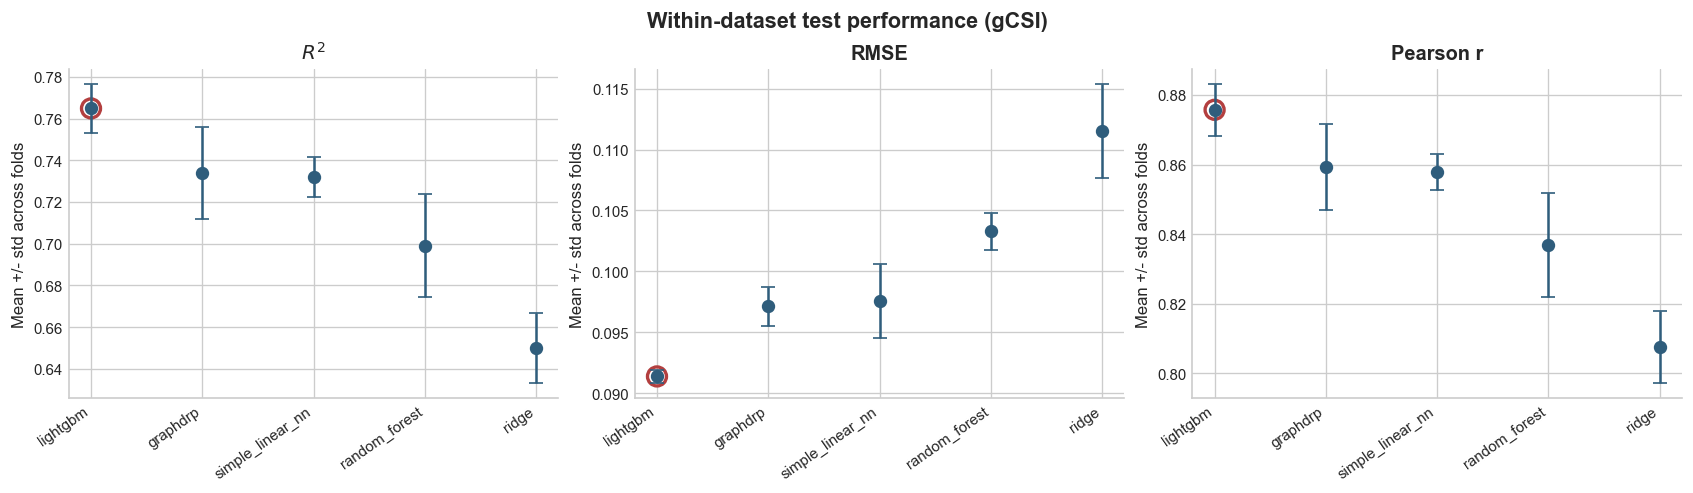

In [2]:
def savefig(name):
    path = FIG_DIR / name
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved: {path}")

plot_df = summary.set_index("model").loc[model_order].reset_index()
metrics = ["r2", "rmse", "pearson"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
x = np.arange(len(plot_df))

for ax, metric in zip(axes, metrics):
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"
    ax.errorbar(
        x,
        plot_df[mean_col],
        yerr=plot_df[std_col],
        fmt="o",
        markersize=7,
        capsize=4,
        linewidth=1.5,
        color="#2f5d7c",
    )
    ax.set_title(metric_specs[metric]["label"])
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["model"], rotation=35, ha="right")
    ax.set_ylabel("Mean +/- std across folds")
    best_idx = plot_df[mean_col].idxmax() if metric_specs[metric]["higher_better"] else plot_df[mean_col].idxmin()
    ax.scatter([best_idx], [plot_df.loc[best_idx, mean_col]], s=130, facecolors="none", edgecolors="#b33f3f", linewidths=2)

fig.suptitle(f"Within-dataset test performance ({dataset_label})", fontsize=13, fontweight="bold")
savefig("fig01_test_metric_mean_std.png")
plt.show()

## Figure 2: Fold variability

Shows whether a model is consistently good or only wins because of one split.

Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/sgcires/new_notebook/results/figures/fig02_fold_variability_test_r2.png


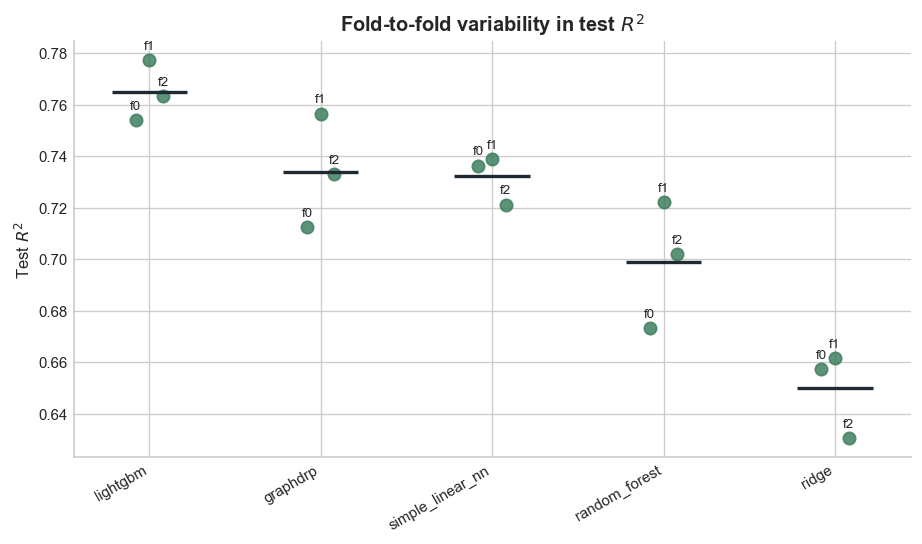

In [3]:
test_df = results[(results["stage"] == "test") & (results["status"] == "ok")].copy()
test_df["model"] = pd.Categorical(test_df["model"], categories=model_order, ordered=True)
test_df = test_df.sort_values(["model", "fold"])

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, model in enumerate(model_order):
    model_df = test_df[test_df["model"] == model].sort_values("fold")
    jitter = np.linspace(-0.08, 0.08, len(model_df)) if len(model_df) > 1 else np.array([0])
    ax.scatter(np.full(len(model_df), i) + jitter, model_df["r2"], s=55, alpha=0.85, label=model if i == 0 else None, color="#3f7f5f")
    ax.hlines(model_df["r2"].mean(), i - 0.22, i + 0.22, color="#1f2933", linewidth=2)
    for x_pos, (_, row) in zip(np.full(len(model_df), i) + jitter, model_df.iterrows()):
        ax.text(x_pos, row["r2"] + 0.003, f"f{int(row['fold'])}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(np.arange(len(model_order)))
ax.set_xticklabels(model_order, rotation=30, ha="right")
ax.set_ylabel("Test $R^2$")
ax.set_title("Fold-to-fold variability in test $R^2$")
savefig("fig02_fold_variability_test_r2.png")
plt.show()

## Figure 3: Validation-to-test gap

This is not train-test overfitting because train metrics are not in the CSV. It compares validation and test performance on the same folds. Large positive `val_r2 - test_r2` means the validation score is more optimistic than the held-out test score.

Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/sgcires/new_notebook/results/figures/fig03_validation_test_gap.png


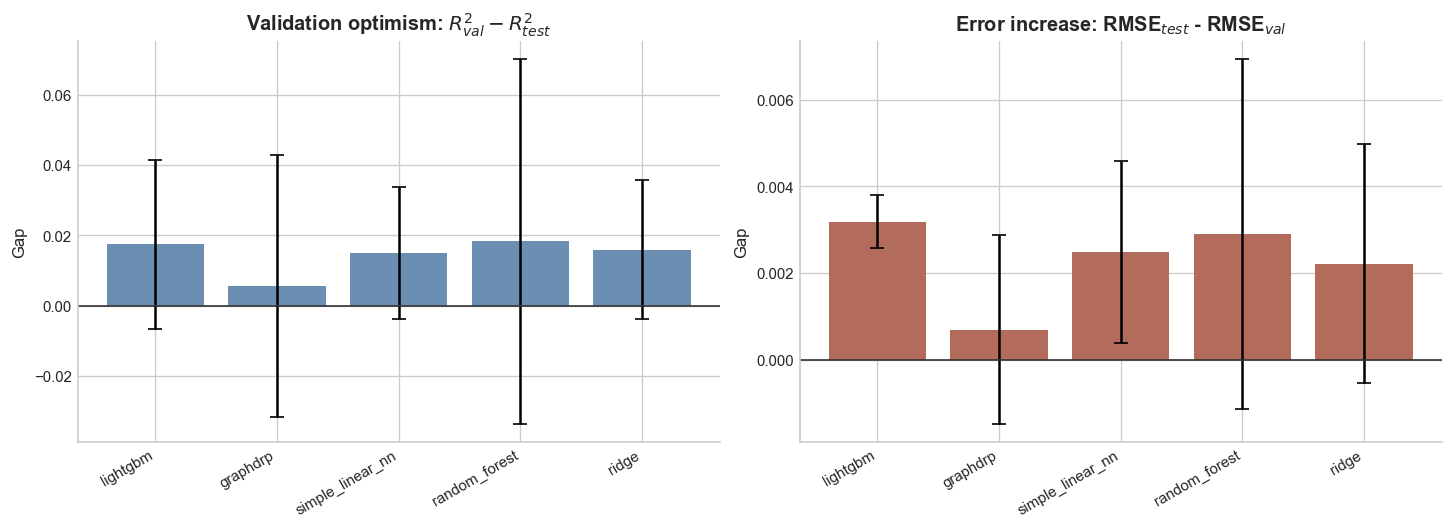

,model,r2_gap_mean,r2_gap_std,rmse_gap_mean,rmse_gap_std
1,lightgbm,0.017468,0.023989,0.003184,0.000604
0,graphdrp,0.005650,0.037195,0.000693,0.002175
4,simple_linear_nn,0.014892,0.018716,0.002481,0.002095
2,random_forest,0.018266,0.051860,0.002901,0.004039
3,ridge,0.015926,0.019779,0.002214,0.002760


In [4]:
wide = (
    results[results["status"] == "ok"]
    .pivot_table(index=["dataset", "fold", "model"], columns="stage", values=["r2", "rmse", "mae", "pearson"])
)
wide.columns = [f"{metric}_{stage}" for metric, stage in wide.columns]
wide = wide.reset_index()
wide["r2_gap_val_minus_test"] = wide["r2_val"] - wide["r2_test"]
wide["rmse_gap_test_minus_val"] = wide["rmse_test"] - wide["rmse_val"]
gap = wide.groupby("model", as_index=False).agg(
    r2_gap_mean=("r2_gap_val_minus_test", "mean"),
    r2_gap_std=("r2_gap_val_minus_test", "std"),
    rmse_gap_mean=("rmse_gap_test_minus_val", "mean"),
    rmse_gap_std=("rmse_gap_test_minus_val", "std"),
)
gap["model"] = pd.Categorical(gap["model"], categories=model_order, ordered=True)
gap = gap.sort_values("model")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), constrained_layout=True)
x = np.arange(len(gap))

axes[0].bar(x, gap["r2_gap_mean"], yerr=gap["r2_gap_std"], capsize=4, color="#6b8fb3")
axes[0].axhline(0, color="#333333", linewidth=1)
axes[0].set_title("Validation optimism: $R^2_{val} - R^2_{test}$")
axes[0].set_ylabel("Gap")

axes[1].bar(x, gap["rmse_gap_mean"], yerr=gap["rmse_gap_std"], capsize=4, color="#b36b5c")
axes[1].axhline(0, color="#333333", linewidth=1)
axes[1].set_title("Error increase: RMSE$_{test}$ - RMSE$_{val}$")
axes[1].set_ylabel("Gap")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(gap["model"], rotation=30, ha="right")

savefig("fig03_validation_test_gap.png")
plt.show()
display(gap)

## Figure 4: Rank stability across folds

This plot discards the raw metric scale and focuses on consistency. Rank 1 is best in a fold.

Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/sgcires/new_notebook/results/figures/fig04_rank_stability_test_r2.png


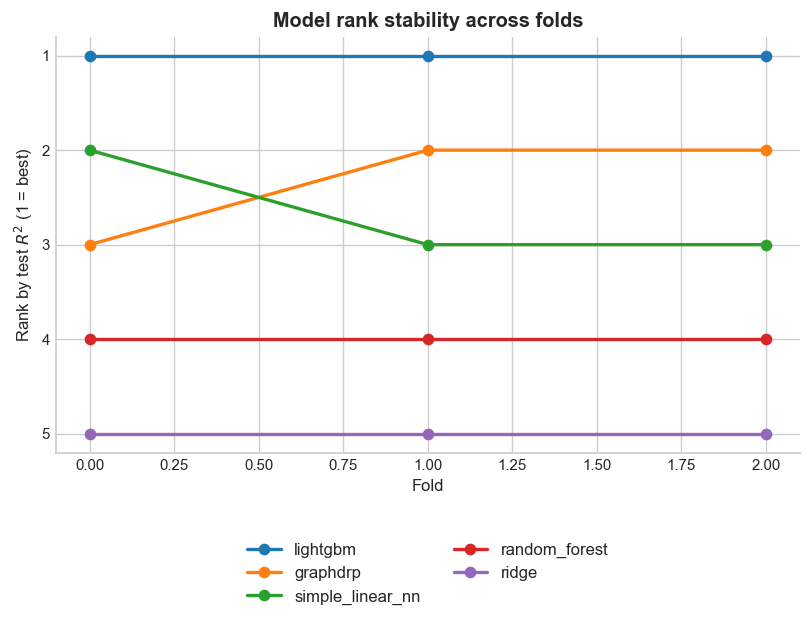

In [5]:
rank_df = test_df.copy()
rank_df["rank_r2"] = rank_df.groupby(["dataset", "fold"])["r2"].rank(ascending=False, method="min")

fig, ax = plt.subplots(figsize=(8, 4.5))
for model in model_order:
    model_df = rank_df[rank_df["model"] == model].sort_values("fold")
    ax.plot(model_df["fold"], model_df["rank_r2"], marker="o", linewidth=2, label=model)

ax.invert_yaxis()
ax.set_yticks(sorted(rank_df["rank_r2"].unique()))
ax.set_xlabel("Fold")
ax.set_ylabel("Rank by test $R^2$ (1 = best)")
ax.set_title("Model rank stability across folds")
ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.18))
savefig("fig04_rank_stability_test_r2.png")
plt.show()

## Figure 5: Accuracy vs training time

This adds information that the metric table usually does not show: the cost-performance trade-off.

Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/sgcires/new_notebook/results/figures/fig05_accuracy_vs_training_time.png


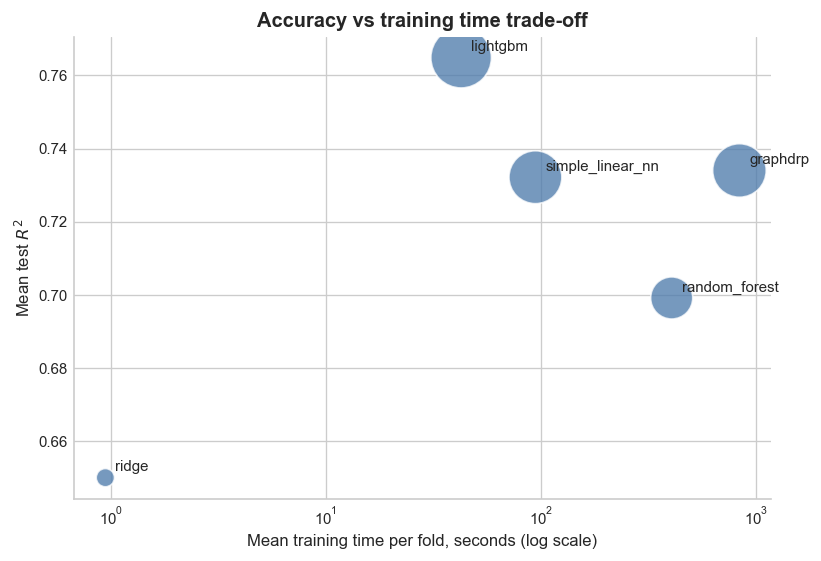

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5))
plot_df = summary.set_index("model").loc[model_order].reset_index()
sizes = 120 + 1200 * (plot_df["pearson_mean"] - plot_df["pearson_mean"].min()) / max(plot_df["pearson_mean"].max() - plot_df["pearson_mean"].min(), 1e-9)

ax.scatter(plot_df["train_seconds_mean"], plot_df["r2_mean"], s=sizes, color="#4f7cac", alpha=0.78, edgecolor="white", linewidth=1)
for _, row in plot_df.iterrows():
    ax.annotate(row["model"], (row["train_seconds_mean"], row["r2_mean"]), xytext=(6, 4), textcoords="offset points", fontsize=9)

ax.set_xscale("log")
ax.set_xlabel("Mean training time per fold, seconds (log scale)")
ax.set_ylabel("Mean test $R^2$")
ax.set_title("Accuracy vs training time trade-off")
savefig("fig05_accuracy_vs_training_time.png")
plt.show()

## Figure 6: Metric agreement

Checks whether models that have higher correlation also have lower absolute error.

Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/sgcires/new_notebook/results/figures/fig06_metric_agreement_rmse_pearson.png


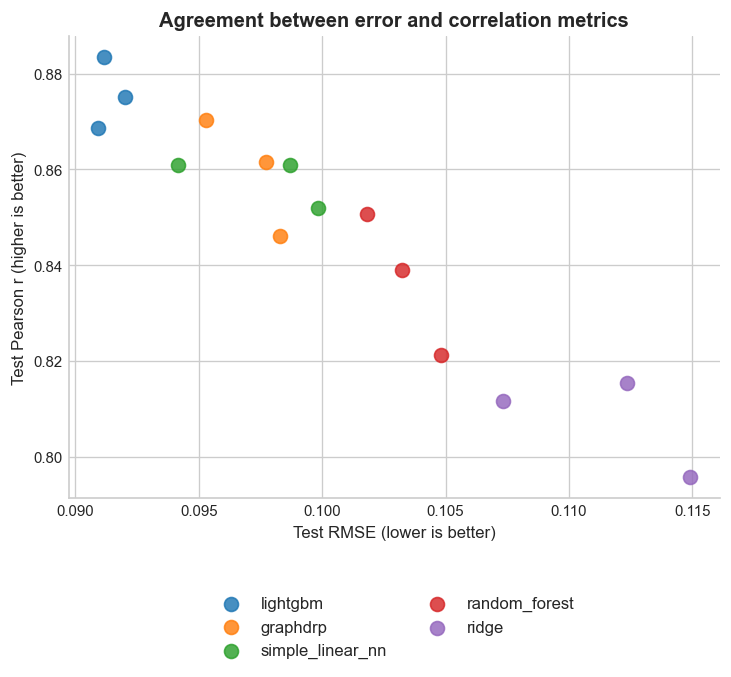

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for model in model_order:
    model_df = test_df[test_df["model"] == model]
    ax.scatter(model_df["rmse"], model_df["pearson"], s=70, alpha=0.82, label=model)

ax.set_xlabel("Test RMSE (lower is better)")
ax.set_ylabel("Test Pearson r (higher is better)")
ax.set_title("Agreement between error and correlation metrics")
ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.18))
savefig("fig06_metric_agreement_rmse_pearson.png")
plt.show()

## Figure 7: Compact formatted summary table

This is useful when the report needs exact values next to the plots.

In [8]:
table = summary.set_index("model").loc[model_order].reset_index().copy()
table["R2"] = table.apply(lambda r: f"{r.r2_mean:.3f} +/- {r.r2_std:.3f}", axis=1)
table["RMSE"] = table.apply(lambda r: f"{r.rmse_mean:.3f} +/- {r.rmse_std:.3f}", axis=1)
table["MAE"] = table.apply(lambda r: f"{r.mae_mean:.3f} +/- {r.mae_std:.3f}", axis=1)
table["Pearson r"] = table.apply(lambda r: f"{r.pearson_mean:.3f} +/- {r.pearson_std:.3f}", axis=1)
table["Train seconds"] = table["train_seconds_mean"].map(lambda x: f"{x:.1f}")
display(table[["model", "folds", "R2", "RMSE", "MAE", "Pearson r", "Train seconds"]])

,model,folds,R2,RMSE,MAE,Pearson r,Train seconds
0,lightgbm,3,0.765 +/- 0.012,0.091 +/- 0.001,0.067 +/- 0.001,0.876 +/- 0.007,42.6
1,graphdrp,3,0.734 +/- 0.022,0.097 +/- 0.002,0.072 +/- 0.003,0.859 +/- 0.012,838.5
2,simple_linear_nn,3,0.732 +/- 0.010,0.098 +/- 0.003,0.075 +/- 0.002,0.858 +/- 0.005,94.3
3,random_forest,3,0.699 +/- 0.025,0.103 +/- 0.002,0.076 +/- 0.002,0.837 +/- 0.015,405.9
4,ridge,3,0.650 +/- 0.017,0.112 +/- 0.004,0.084 +/- 0.003,0.808 +/- 0.010,0.9


## Figure 8: Paired validation-test performance

Inspired by benchmark figures that compare predicted performance across evaluation settings. Each line connects validation and test performance for the same model and fold.

Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/sgcires/new_notebook/results/figures/fig08_paired_validation_test_shift.png


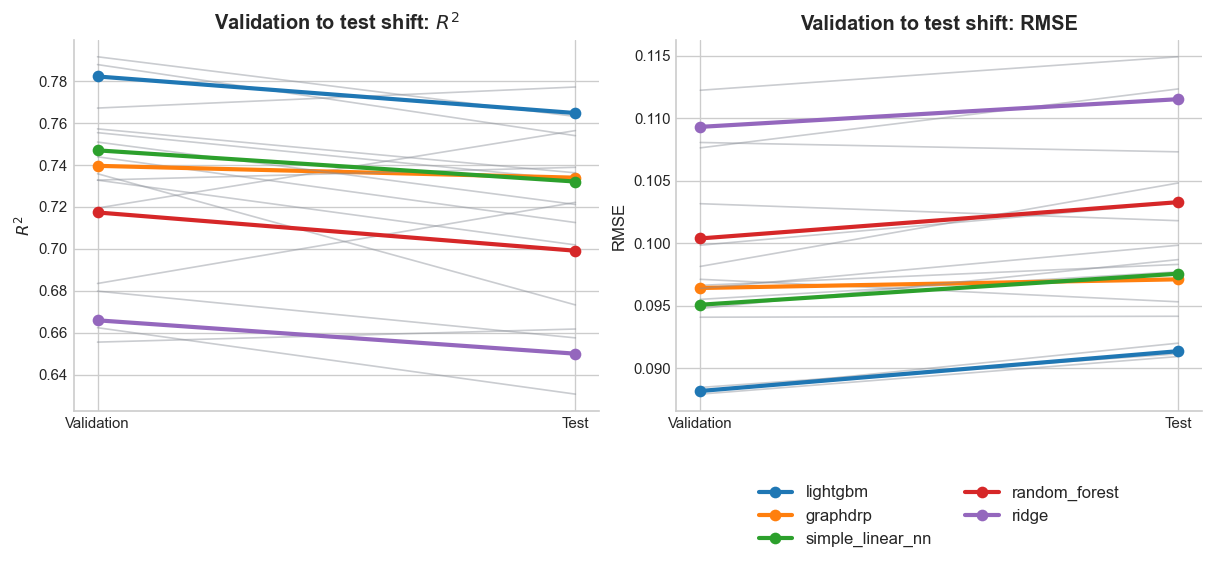

In [9]:
paired = wide.copy()
paired["model"] = pd.Categorical(paired["model"], categories=model_order, ordered=True)
paired = paired.sort_values(["model", "fold"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), constrained_layout=True)
for ax, metric, ylabel in [(axes[0], "r2", "$R^2$"), (axes[1], "rmse", "RMSE")]:
    for i, model in enumerate(model_order):
        model_df = paired[paired["model"] == model]
        for _, row in model_df.iterrows():
            ax.plot([0, 1], [row[f"{metric}_val"], row[f"{metric}_test"]], color="#8a8f98", alpha=0.45, linewidth=1)
        ax.plot([0, 1], [model_df[f"{metric}_val"].mean(), model_df[f"{metric}_test"].mean()], marker="o", linewidth=2.5, label=model)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Validation", "Test"])
    ax.set_ylabel(ylabel)
    ax.set_title(f"Validation to test shift: {ylabel}")

axes[1].legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.16))
savefig("fig08_paired_validation_test_shift.png")
plt.show()

## Figure 9: Feature size, training cost, and performance

The reviewed papers emphasize that architecture and input representation matter. This bubble plot uses the outputs available here: feature count, training time, and test performance.

Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/sgcires/new_notebook/results/figures/fig09_feature_cost_performance_bubble.png


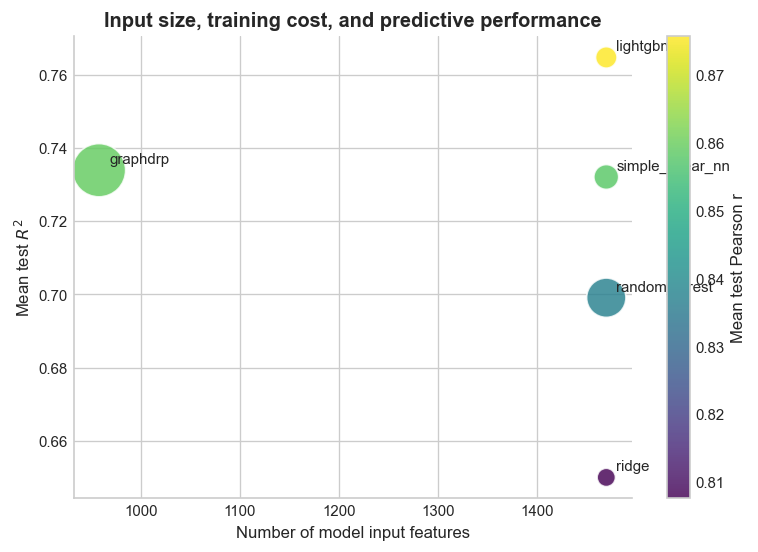

,model,n_features,train_seconds,r2,pearson
1,lightgbm,1470.0,42.588576,0.764856,0.875717
0,graphdrp,958.0,838.499475,0.733995,0.859294
4,simple_linear_nn,1470.0,94.344188,0.732149,0.857932
2,random_forest,1470.0,405.932170,0.699114,0.836981
3,ridge,1470.0,0.943376,0.649948,0.807605


In [10]:
complexity = (
    results[(results["stage"] == "test") & (results["status"] == "ok")]
    .groupby("model", as_index=False)
    .agg(
        n_features=("n_features", "mean"),
        train_seconds=("train_seconds", "mean"),
        r2=("r2", "mean"),
        pearson=("pearson", "mean"),
    )
)
complexity["model"] = pd.Categorical(complexity["model"], categories=model_order, ordered=True)
complexity = complexity.sort_values("model")
bubble_size = 120 + 900 * complexity["train_seconds"] / complexity["train_seconds"].max()

fig, ax = plt.subplots(figsize=(7.5, 5))
scatter = ax.scatter(
    complexity["n_features"],
    complexity["r2"],
    s=bubble_size,
    c=complexity["pearson"],
    cmap="viridis",
    alpha=0.82,
    edgecolor="white",
    linewidth=1,
)
for _, row in complexity.iterrows():
    ax.annotate(row["model"], (row["n_features"], row["r2"]), xytext=(6, 4), textcoords="offset points", fontsize=9)

ax.set_xlabel("Number of model input features")
ax.set_ylabel("Mean test $R^2$")
ax.set_title("Input size, training cost, and predictive performance")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Mean test Pearson r")
savefig("fig09_feature_cost_performance_bubble.png")
plt.show()
display(complexity)

## Figure 10: Model performance by evaluation stage

Grouped bar charts comparing each model across available stages. If the results CSV includes `train`, `val`, and `test`, all three are plotted. The current CSV contains `val` and `test`, so this plot shows validation-test shift.

Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/sgcires/new_notebook/results/figures/fig10_model_stage_grouped_bars.png


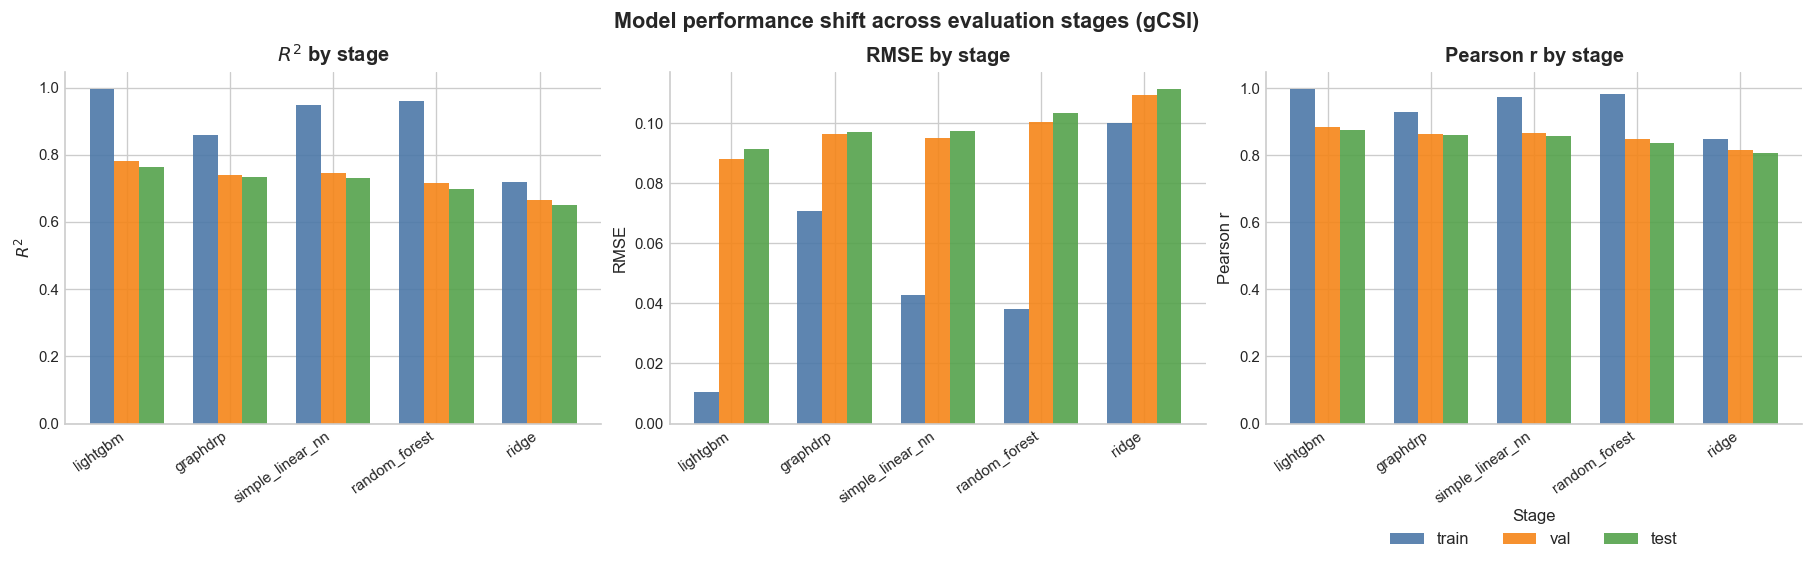

In [11]:
stage_order = [stage for stage in ["train", "val", "test"] if stage in results["stage"].unique()]
if "train" not in stage_order:
    print("No train-stage metrics found in results.csv; plotting available stages only:", stage_order)

stage_metric = (
    results[results["status"] == "ok"]
    .groupby(["model", "stage"], as_index=False)
    .agg(r2=("r2", "mean"), rmse=("rmse", "mean"), pearson=("pearson", "mean"))
)
stage_metric["model"] = pd.Categorical(stage_metric["model"], categories=model_order, ordered=True)
stage_metric["stage"] = pd.Categorical(stage_metric["stage"], categories=stage_order, ordered=True)
stage_metric = stage_metric.sort_values(["model", "stage"])

colors = {"train": "#4c78a8", "val": "#f58518", "test": "#54a24b"}
metrics_to_plot = [("r2", "$R^2$"), ("rmse", "RMSE"), ("pearson", "Pearson r")]
x = np.arange(len(model_order))
width = min(0.24, 0.72 / max(len(stage_order), 1))
offsets = (np.arange(len(stage_order)) - (len(stage_order) - 1) / 2) * width

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
for ax, (metric, ylabel) in zip(axes, metrics_to_plot):
    for offset, stage in zip(offsets, stage_order):
        values = []
        for model in model_order:
            match = stage_metric[(stage_metric["model"] == model) & (stage_metric["stage"] == stage)]
            values.append(match[metric].iloc[0] if len(match) else np.nan)
        ax.bar(x + offset, values, width=width, label=stage, color=colors.get(stage, "#8a8f98"), alpha=0.9)
    ax.set_title(f"{ylabel} by stage")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=35, ha="right")

axes[-1].legend(title="Stage", loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=len(stage_order))
fig.suptitle(f"Model performance shift across evaluation stages ({dataset_label})", fontsize=13, fontweight="bold")
savefig("fig10_model_stage_grouped_bars.png")
plt.show()

## Figure 11: Paper-style grouped violin plot

A grouped violin plot similar to benchmark papers: x-axis is dataset, color is model, and each violin summarizes fold-level test R2. Dashed horizontal markers show the 25th percentile, median, and 75th percentile. With the current one-dataset/three-fold CSV this is only a style preview; it becomes genuinely informative after running more datasets and folds.


Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/sgcires/new_notebook/results/figures/fig11_paper_style_violin_r2.png


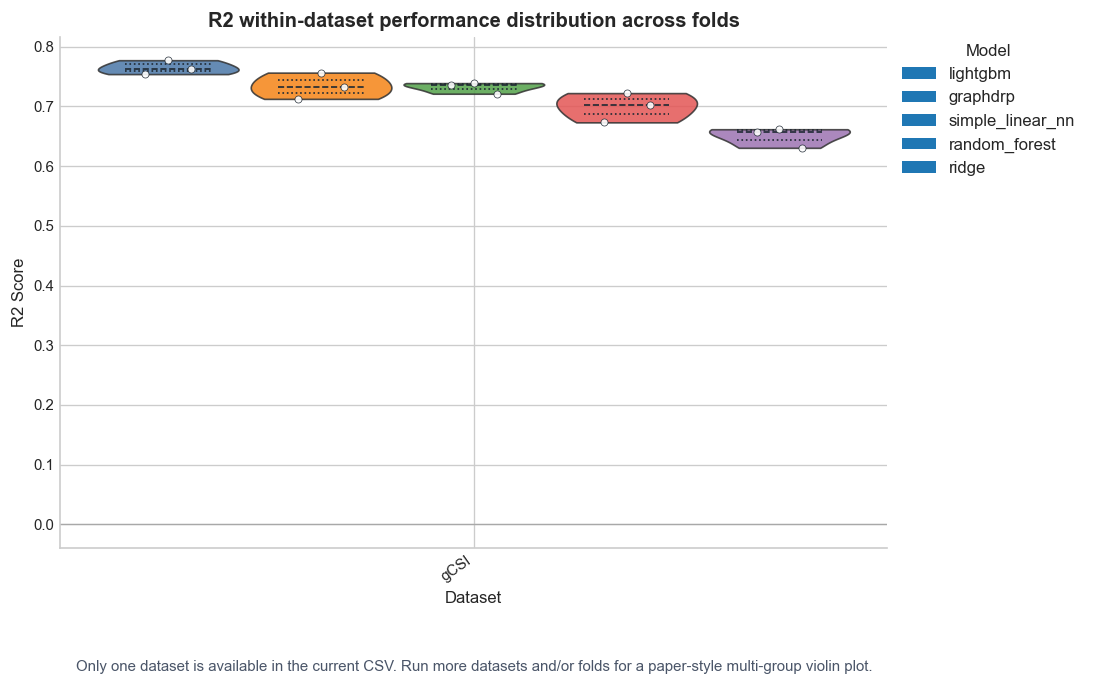

In [12]:
paper_violin_df = results[(results["stage"] == "test") & (results["status"] == "ok")].copy()
paper_violin_df["model"] = pd.Categorical(paper_violin_df["model"], categories=model_order, ordered=True)

dataset_order = [d for d in ["gCSI", "CCLE", "GDSCv2", "GDSCv1", "CTRPv2"] if d in paper_violin_df["dataset"].unique()]
if not dataset_order:
    dataset_order = sorted(paper_violin_df["dataset"].unique())

color_cycle = ["#4c78a8", "#f58518", "#54a24b", "#e45756", "#9d75b3", "#8c613c", "#72b7b2"]
model_colors = {model: color_cycle[i % len(color_cycle)] for i, model in enumerate(model_order)}

fig, ax = plt.subplots(figsize=(max(9, 2.6 * len(dataset_order)), 5.6), constrained_layout=True)
base_positions = np.arange(len(dataset_order))
cluster_width = 0.72
single_width = cluster_width / max(len(model_order), 1)
positions_by_model = {}

for m_idx, model in enumerate(model_order):
    offset = -cluster_width / 2 + single_width / 2 + m_idx * single_width
    positions = base_positions + offset
    positions_by_model[model] = positions
    data = []
    valid_positions = []
    for d_idx, dataset in enumerate(dataset_order):
        values = paper_violin_df.loc[
            (paper_violin_df["dataset"] == dataset) & (paper_violin_df["model"] == model),
            "r2",
        ].dropna().to_numpy()
        if len(values) >= 2:
            data.append(values)
            valid_positions.append(positions[d_idx])
        elif len(values) == 1:
            ax.scatter(positions[d_idx], values[0], color=model_colors[model], s=60, edgecolor="#222222", linewidth=0.8, zorder=4)

    if data:
        parts = ax.violinplot(
            data,
            positions=valid_positions,
            widths=single_width * 0.92,
            showmeans=False,
            showmedians=False,
            showextrema=False,
        )
        for body in parts["bodies"]:
            body.set_facecolor(model_colors[model])
            body.set_edgecolor("#333333")
            body.set_alpha(0.86)
            body.set_linewidth(1.0)

        for pos, values in zip(valid_positions, data):
            q1, med, q3 = np.percentile(values, [25, 50, 75])
            half = single_width * 0.28
            ax.hlines([q1, med, q3], pos - half, pos + half, colors="#1f2933", linestyles=[":", "--", ":"], linewidth=1.0, zorder=5)
            jitter = np.linspace(-single_width * 0.15, single_width * 0.15, len(values)) if len(values) > 1 else np.array([0])
            ax.scatter(np.full(len(values), pos) + jitter, values, color="white", s=18, edgecolor="#1f2933", linewidth=0.45, zorder=6, alpha=0.9)

for model in model_order:
    ax.bar([], [], color=model_colors[model], edgecolor="#333333", label=model)

ax.axhline(0, color="#a0a0a0", linewidth=0.8, alpha=0.8)
ax.set_xticks(base_positions)
ax.set_xticklabels(dataset_order, rotation=35, ha="right")
ax.set_xlabel("Dataset")
ax.set_ylabel("R2 Score")
ax.set_title("R2 within-dataset performance distribution across folds")
ax.legend(title="Model", loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)

if len(dataset_order) == 1:
    ax.text(
        0.5,
        -0.22,
        "Only one dataset is available in the current CSV. Run more datasets and/or folds for a paper-style multi-group violin plot.",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9,
        color="#4a5568",
    )

savefig("fig11_paper_style_violin_r2.png")
plt.show()
